# 04c — Matched-Control Test + Regional/Seasonal FD Driver Diagnostics (M2A)

## Tujuan
Menguji apakah sinyal **wet / cool / low-VPD** sebelum rapid-drying initiation tetap muncul setelah setiap FD dibandingkan dengan kondisi **non-FD** yang mempunyai:

1. grid yang sama;
2. pentad kalender yang sama;
3. tahun berbeda;
4. RZSM percentile awal yang serupa (`>=P40`, tolerance default ±5 percentile points);
5. tidak ada M2A event start di sekitar target control (default ±2 pentad).

Matching dilakukan **with replacement** dan kandidat dengan RZSM lag-0 paling dekat dipilih. Pair difference didefinisikan sebagai **FD − matched control**.

### Inferensi
Semua pair diringkas dahulu per **event year**, lalu 95% CI dihitung dengan **year-block bootstrap**. Ini mencegah satu tahun luas seperti 2003 mendapat ribuan “suara independen”.

### Extension Figure 4
Notebook menghasilkan:
- Figure 4A: nasional FD vs matched control;
- Figure 4B: nasional paired difference;
- Figure 4C: paired difference per macro-island;
- Figure 4D: paired difference per musim onset (DJF/MAM/JJA/SON).

**Guardrail:** ini matched-control association test, bukan causal attribution.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
warnings.filterwarnings('once')

BASE = Path(r'D:\ERA5_LAND')
DETECTION_FILE = BASE/'output_fd_03b_sensitivity'/'fd_detection_M2A_1995_2025_indonesia.nc'
ANOMALY_FILE = BASE/'output_fd_04_drivers'/'meteorological_anomaly_cube_timeindex_1995_2025.nc'
PERCENTILE_FILE = BASE/'output_rzsm'/'rzsm_percentile_gringorten_1995_2025.nc'
ISLAND_MASK_FILE = BASE/'output_fd_03c_island_M2A'/'fd_island_masks_era5land_grid.nc'
OUTPUT_DIR = BASE/'output_fd_04c_matched_control'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_YEAR, END_YEAR = 1996, 2024
YEARS = np.arange(START_YEAR, END_YEAR+1, dtype=int)
LAGS = np.arange(-6, 7, dtype=int)
RZSM_MATCH_TOL = 5.0
CONTROL_EXCLUSION_RADIUS = 2
MIN_CONTROL_RZSM = 40.0
BOOTSTRAP_REPS = 5000
RANDOM_SEED = 42
MIN_YEARS_FOR_CI = 10
MIN_PAIRS_PER_YEAR_STRATUM = 20
FIG_DPI = 600
VARS = {
    'tp_anom_mm':'Precipitation anomaly (mm pentad$^{-1}$)',
    't2m_anom_c':'T2m anomaly (°C)',
    'vpd_anom_kpa':'VPD anomaly (kPa)',
}
MATCH_FILE = OUTPUT_DIR/'matched_pairs_M2A_1996_2024.csv.gz'
ANNUAL_FILE = OUTPUT_DIR/'matched_control_annual_strata.csv.gz'
BOOT_FILE = OUTPUT_DIR/'matched_control_yearblock_bootstrap95.csv'
ANTECEDENT_FILE = OUTPUT_DIR/'matched_control_antecedent_summary.csv'
print('Output:', OUTPUT_DIR)

Output: D:\ERA5_LAND\output_fd_04c_matched_control


## 1. Buka data dan exact alignment QC

In [2]:
for p in [DETECTION_FILE, ANOMALY_FILE, PERCENTILE_FILE, ISLAND_MASK_FILE]:
    if not p.exists(): raise FileNotFoundError(p)
fd = xr.open_dataset(DETECTION_FILE, mask_and_scale=False)
anom = xr.open_dataset(ANOMALY_FILE)
pct_ds = xr.open_dataset(PERCENTILE_FILE)
islands = xr.open_dataset(ISLAND_MASK_FILE)
for v in ['fd_event_start','valid_grid_mask']:
    if v not in fd: raise KeyError(v)
for v in VARS:
    if v not in anom: raise KeyError(v)
if 'rzsm_percentile' not in pct_ds: raise KeyError('rzsm_percentile')
if fd.sizes['time_index'] != anom.sizes['time_index']: raise ValueError('time mismatch')
for c in ['year','pentad']:
    if not np.array_equal(fd[c].values.astype(int), anom[c].values.astype(int)):
        raise ValueError(f'{c} mismatch between detection and anomaly')
for other,name in [(anom,'anomaly'),(islands,'island mask')]:
    if not np.allclose(fd.latitude.values, other.latitude.values): raise ValueError(f'latitude mismatch: {name}')
    if not np.allclose(fd.longitude.values, other.longitude.values): raise ValueError(f'longitude mismatch: {name}')
year_all = fd.year.values.astype(int); pentad_all = fd.pentad.values.astype(int)
lat = fd.latitude.values.astype(float); lon = fd.longitude.values.astype(float)
valid_np = np.asarray(fd.valid_grid_mask.values==1, bool)
time_lookup={(int(y),int(p)):int(i) for i,(y,p) in enumerate(zip(year_all,pentad_all))}
pos_matrix=np.array([[time_lookup[(int(y),p)] for p in range(1,74)] for y in YEARS], dtype=int)
print('Alignment PASS:', year_all[0], pentad_all[0], '->', year_all[-1], pentad_all[-1])
print('Valid grids:', int(valid_np.sum()))

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Alignment PASS: 1995 1 -> 2025 73
Valid grids: 14857


## 2. Macro-island dan season onset

In [3]:
island_stack=islands['island_valid_grid_mask'].transpose('island','latitude','longitude').load()
island_names=[str(x) for x in island_stack.island.values]
region_idx=np.full(valid_np.shape,-1,dtype=np.int16)
for i in range(len(island_names)):
    region_idx[np.asarray(island_stack.isel(island=i).values>0)] = i

def pentad_to_month(p):
    day=min(365,(int(p)-1)*5+3)
    return (pd.Timestamp('2001-01-01')+pd.Timedelta(days=day-1)).month

def month_to_season(m):
    return 'DJF' if m in (12,1,2) else ('MAM' if m in (3,4,5) else ('JJA' if m in (6,7,8) else 'SON'))

pentad_month={p:pentad_to_month(p) for p in range(1,74)}
pentad_season={p:month_to_season(pentad_month[p]) for p in range(1,74)}
print('Regions:', island_names)

Regions: ['Sumatra', 'Jawa', 'Kalimantan', 'Sulawesi', 'Bali-Nusa Tenggara', 'Maluku', 'Papua']


## 3. Build matched pairs
Kontrol mempunyai **grid + calendar pentad yang sama** dengan FD dan initial RZSM percentile yang serupa. Ini adalah tes utama untuk memisahkan sinyal antecedent dari efek conditioning `RZSM >= P40`.

In [4]:
pct = pct_ds['rzsm_percentile']

def percentile_same_pentad(p):
    if {'year','pentad'}.issubset(pct.dims):
        return np.asarray(pct.sel(year=YEARS,pentad=int(p)).transpose('year','latitude','longitude').load().values, np.float32)
    if 'time_index' in pct.dims:
        return np.asarray(pct.isel(time_index=pos_matrix[:,int(p)-1]).transpose('time_index','latitude','longitude').load().values, np.float32)
    raise ValueError(f'Unsupported percentile dims: {pct.dims}')

def build_matches():
    frames=[]; total_events=0
    for p in range(1,74):
        base=pos_matrix[:,p-1]
        start=np.asarray(fd.fd_event_start.isel(time_index=base).load().values==1,bool)
        start &= valid_np[None,:,:]
        near=np.zeros_like(start,bool)
        for off in range(-CONTROL_EXCLUSION_RADIUS,CONTROL_EXCLUSION_RADIUS+1):
            near |= np.asarray(fd.fd_event_start.isel(time_index=base+off).load().values==1,bool)
        q=percentile_same_pentad(p)
        ey,iy,ix=np.nonzero(start); n=len(ey); total_events += n
        if n==0: continue
        qe=q[ey,iy,ix]
        cq=q[:,iy,ix].T
        cn=near[:,iy,ix].T
        dist=np.abs(cq-qe[:,None])
        eligible=np.isfinite(cq)&np.isfinite(qe[:,None])&(cq>=MIN_CONTROL_RZSM)&(dist<=RZSM_MATCH_TOL)&(~cn)
        eligible[np.arange(n),ey]=False
        score=np.where(eligible,dist,np.inf)
        cy=np.argmin(score,axis=1); best=score[np.arange(n),cy]; ok=np.isfinite(best)
        if not ok.any():
            print(f'P{p:02d}: events={n:,}, matched=0'); continue
        ey2,iy2,ix2,cy2=ey[ok],iy[ok],ix[ok],cy[ok]
        rc=region_idx[iy2,ix2]
        region=np.array([island_names[k] if k>=0 else 'UNASSIGNED' for k in rc],object)
        f=pd.DataFrame({
            'event_year':YEARS[ey2], 'control_year':YEARS[cy2], 'pentad':p,
            'month':pentad_month[p], 'season':pentad_season[p],
            'latitude_index':iy2.astype(np.int16), 'longitude_index':ix2.astype(np.int16),
            'latitude':lat[iy2], 'longitude':lon[ix2], 'region':region,
            'event_time_index':base[ey2], 'control_time_index':base[cy2],
            'event_rzsm_pct0':qe[ok], 'control_rzsm_pct0':cq[ok,cy2],
            'rzsm_abs_mismatch_pp':np.abs(qe[ok]-cq[ok,cy2]),
            'area_weight':np.cos(np.deg2rad(lat[iy2]))
        })
        frames.append(f)
        print(f'P{p:02d}: events={n:,}, matched={len(f):,} ({100*len(f)/n:.1f}%)')
    return pd.concat(frames,ignore_index=True), total_events

if MATCH_FILE.exists():
    print('Using existing:', MATCH_FILE)
    matches=pd.read_csv(MATCH_FILE)
    total_events=int(fd.fd_event_start.isel(time_index=np.ravel(pos_matrix)).where(fd.valid_grid_mask==1,0).sum().compute().item())
else:
    matches,total_events=build_matches()
    matches.to_csv(MATCH_FILE,index=False,compression='gzip')
print('Total starts:',f'{total_events:,}','Matched:',f'{len(matches):,}',f'Rate={100*len(matches)/total_events:.2f}%')

P01: events=10,588, matched=10,149 (95.9%)
P02: events=7,315, matched=6,968 (95.3%)
P03: events=11,677, matched=11,214 (96.0%)
P04: events=11,474, matched=11,065 (96.4%)
P05: events=7,644, matched=7,369 (96.4%)
P06: events=6,367, matched=6,109 (95.9%)
P07: events=9,019, matched=8,705 (96.5%)
P08: events=10,661, matched=10,364 (97.2%)
P09: events=6,922, matched=6,702 (96.8%)
P10: events=7,888, matched=7,622 (96.6%)
P11: events=11,649, matched=11,123 (95.5%)
P12: events=12,513, matched=12,043 (96.2%)
P13: events=8,064, matched=7,690 (95.4%)
P14: events=10,156, matched=9,784 (96.3%)
P15: events=11,850, matched=11,362 (95.9%)
P16: events=11,058, matched=10,627 (96.1%)
P17: events=8,879, matched=8,504 (95.8%)
P18: events=8,558, matched=8,282 (96.8%)
P19: events=8,189, matched=7,905 (96.5%)
P20: events=9,536, matched=9,141 (95.9%)
P21: events=8,381, matched=8,059 (96.2%)
P22: events=11,130, matched=10,665 (95.8%)
P23: events=9,325, matched=8,709 (93.4%)
P24: events=10,217, matched=9,585 (93.

## 4. Matching QC

,n_event_starts,n_matched_pairs,match_rate_percent,median_abs_rzsm_mismatch_pp,p95_abs_rzsm_mismatch_pp,max_abs_rzsm_mismatch_pp,same_year_pairs,controls_below_p40
0,559676,535971,95.764514,3.213367,3.213371,4.820053,0,0


,region,matched_pairs
0,Bali-Nusa Tenggara,7374
1,Jawa,21400
2,Kalimantan,165299
3,Maluku,15219
4,Papua,136958
5,Sulawesi,43969
6,Sumatra,142586
7,UNASSIGNED,3166


,season,matched_pairs
0,DJF,164454
1,JJA,105821
2,MAM,177992
3,SON,87704


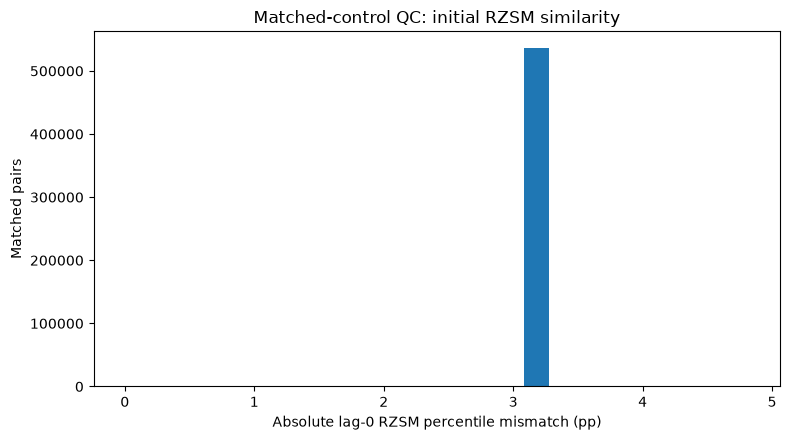

In [5]:
qc=pd.DataFrame([{
 'n_event_starts':int(total_events),'n_matched_pairs':int(len(matches)),
 'match_rate_percent':100*len(matches)/total_events,
 'median_abs_rzsm_mismatch_pp':matches.rzsm_abs_mismatch_pp.median(),
 'p95_abs_rzsm_mismatch_pp':matches.rzsm_abs_mismatch_pp.quantile(.95),
 'max_abs_rzsm_mismatch_pp':matches.rzsm_abs_mismatch_pp.max(),
 'same_year_pairs':int((matches.event_year==matches.control_year).sum()),
 'controls_below_p40':int((matches.control_rzsm_pct0<MIN_CONTROL_RZSM).sum())}])
display(qc)
qc.to_csv(OUTPUT_DIR/'matching_qc_summary.csv',index=False)
assert qc.same_year_pairs.iloc[0]==0
assert qc.controls_below_p40.iloc[0]==0
assert qc.max_abs_rzsm_mismatch_pp.iloc[0] <= RZSM_MATCH_TOL+1e-6

display(matches.groupby('region',as_index=False).size().rename(columns={'size':'matched_pairs'}))
display(matches.groupby('season',as_index=False).size().rename(columns={'size':'matched_pairs'}))
fig,ax=plt.subplots(figsize=(8,4.5)); ax.hist(matches.rzsm_abs_mismatch_pp.dropna(),bins=25)
ax.set(xlabel='Absolute lag-0 RZSM percentile mismatch (pp)',ylabel='Matched pairs',title='Matched-control QC: initial RZSM similarity')
fig.tight_layout(); fig.savefig(OUTPUT_DIR/'Figure_MC_QC_RZSM_mismatch.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()

## 5. Sample meteorology untuk FD dan control
Dibaca **satu calendar-year block sekali**, lalu dipakai untuk semua pair. Data 1995 dan 2025 berfungsi sebagai ±6 pentad buffer untuk 1996 dan 2024.

In [6]:
n=len(matches); nl=len(LAGS)
event_values={v:np.full((n,nl),np.nan,np.float32) for v in VARS}
control_values={v:np.full((n,nl),np.nan,np.float32) for v in VARS}
eyear=matches.event_year.to_numpy(int); cyear=matches.control_year.to_numpy(int)
pent=matches.pentad.to_numpy(int); iy=matches.latitude_index.to_numpy(int); ix=matches.longitude_index.to_numpy(int)
for y in YEARS:
    t0=time_lookup[(int(y),1)]; t1=time_lookup[(int(y),73)]+1
    lo=t0+int(LAGS.min()); hi=t1+int(LAGS.max())
    b=anom[list(VARS)].isel(time_index=slice(lo,hi)).load()
    bn={v:np.asarray(b[v].values,np.float32) for v in VARS}
    ei=np.flatnonzero(eyear==y)
    if ei.size:
        base=(pent[ei]-1)-int(LAGS.min())
        for j,lag in enumerate(LAGS):
            pos=base+int(lag)
            for v in VARS: event_values[v][ei,j]=bn[v][pos,iy[ei],ix[ei]]
    ci=np.flatnonzero(cyear==y)
    if ci.size:
        base=(pent[ci]-1)-int(LAGS.min())
        for j,lag in enumerate(LAGS):
            pos=base+int(lag)
            for v in VARS: control_values[v][ci,j]=bn[v][pos,iy[ci],ix[ci]]
    print(y,'event=',ei.size,'control=',ci.size)
print('Sampling complete')

1996 event= 26438 control= 23553
1997 event= 24804 control= 15605
1998 event= 11330 control= 23422
1999 event= 15025 control= 25313
2000 event= 18657 control= 23570
2001 event= 22072 control= 22463
2002 event= 28786 control= 17834
2003 event= 25529 control= 20273
2004 event= 31807 control= 16793
2005 event= 16649 control= 23618
2006 event= 20728 control= 19915
2007 event= 16078 control= 23098
2008 event= 17751 control= 19354
2009 event= 21198 control= 17767
2010 event= 11449 control= 20488
2011 event= 12716 control= 20441
2012 event= 16422 control= 18380
2013 event= 13106 control= 18880
2014 event= 18655 control= 16589
2015 event= 22463 control= 15660
2016 event= 8110 control= 18723
2017 event= 9401 control= 18832
2018 event= 19741 control= 15019
2019 event= 22698 control= 12330
2020 event= 11117 control= 16135
2021 event= 16188 control= 14277
2022 event= 22152 control= 12330
2023 event= 18126 control= 12324
2024 event= 16775 control= 12985
Sampling complete


## 6. Year-block summary
**Sederhananya:** semua pair dalam tahun yang sama dirata-ratakan dulu. Jadi 2003 = satu annual block, 2010 = satu annual block, dst. Confidence interval kemudian membandingkan kestabilan pola **antar-tahun**, bukan menganggap semua grid independen.

In [7]:
def wmean(x,w):
    x=np.asarray(x,float); w=np.asarray(w,float); ok=np.isfinite(x)&np.isfinite(w)&(w>0)
    return np.nan if not ok.any() else float(np.sum(x[ok]*w[ok])/np.sum(w[ok]))
weights=matches.area_weight.to_numpy(float); reg=matches.region.astype(str).to_numpy(); sea=matches.season.astype(str).to_numpy()
rows=[]
for y in YEARS:
    yi=np.flatnonzero(eyear==y)
    if not yi.size: continue
    groups=[('national','Indonesia',yi)]
    for r in island_names:
        idx=yi[reg[yi]==r]
        if idx.size>=MIN_PAIRS_PER_YEAR_STRATUM: groups.append(('region',r,idx))
    for s in ['DJF','MAM','JJA','SON']:
        idx=yi[sea[yi]==s]
        if idx.size>=MIN_PAIRS_PER_YEAR_STRATUM: groups.append(('season',s,idx))
    for scope,stratum,idx in groups:
        w=weights[idx]
        for j,lag in enumerate(LAGS):
            for v in VARS:
                ev=event_values[v][idx,j]; ct=control_values[v][idx,j]
                rows.append({'scope':scope,'stratum':stratum,'event_year':int(y),'lag':int(lag),'variable':v,
                             'n_pairs':int(idx.size),'event_mean':wmean(ev,w),'control_mean':wmean(ct,w),'difference_mean':wmean(ev-ct,w)})
annual=pd.DataFrame(rows); annual.to_csv(ANNUAL_FILE,index=False,compression='gzip')
display(annual.head())

,scope,stratum,event_year,lag,variable,n_pairs,event_mean,control_mean,difference_mean
0,national,Indonesia,1996,-6,tp_anom_mm,26438,-3.323534,1.205047,-4.528581
1,national,Indonesia,1996,-6,t2m_anom_c,26438,-0.275436,-0.018155,-0.257281
2,national,Indonesia,1996,-6,vpd_anom_kpa,26438,-0.009619,-0.006109,-0.003509
3,national,Indonesia,1996,-5,tp_anom_mm,26438,-0.700280,-0.161994,-0.538286
4,national,Indonesia,1996,-5,t2m_anom_c,26438,-0.371862,-0.016527,-0.355335


## 7. Paired year-block bootstrap 95% CI

In [8]:
rng=np.random.default_rng(RANDOM_SEED)
def boot_ci(sub):
    x=sub[['event_mean','control_mean','difference_mean']].dropna().to_numpy(float); n=len(x)
    out={'n_years':n}
    if n<MIN_YEARS_FOR_CI:
        for stem in ['event','control','difference']: out.update({f'{stem}_mean':np.nan,f'{stem}_ci_low':np.nan,f'{stem}_ci_high':np.nan})
        return out
    idx=rng.integers(0,n,size=(BOOTSTRAP_REPS,n)); b=x[idx].mean(axis=1)
    for k,stem in enumerate(['event','control','difference']):
        out.update({f'{stem}_mean':float(x[:,k].mean()),f'{stem}_ci_low':float(np.quantile(b[:,k],.025)),f'{stem}_ci_high':float(np.quantile(b[:,k],.975))})
    return out
br=[]
for (scope,stratum,lag,v),sub in annual.groupby(['scope','stratum','lag','variable'],sort=False):
    br.append({'scope':scope,'stratum':stratum,'lag':int(lag),'variable':v,**boot_ci(sub)})
boot=pd.DataFrame(br); boot.to_csv(BOOT_FILE,index=False); display(boot.head())

,scope,stratum,lag,variable,n_years,event_mean,event_ci_low,event_ci_high,control_mean,control_ci_low,control_ci_high,difference_mean,difference_ci_low,difference_ci_high
0,national,Indonesia,-6,tp_anom_mm,29,-2.774581,-4.576525,-1.094867,-0.001210,-0.312642,0.309289,-2.773371,-4.743442,-0.935088
1,national,Indonesia,-6,t2m_anom_c,29,-0.028856,-0.106390,0.055338,-0.034139,-0.043029,-0.026107,0.005283,-0.076904,0.093829
2,national,Indonesia,-6,vpd_anom_kpa,29,0.001759,-0.005877,0.009600,-0.005423,-0.006865,-0.004113,0.007182,-0.000591,0.015139
3,national,Indonesia,-5,tp_anom_mm,29,-1.876013,-3.588155,-0.138330,-0.247413,-0.496727,0.004914,-1.628600,-3.399397,0.163332
4,national,Indonesia,-5,t2m_anom_c,29,-0.051282,-0.130438,0.032630,-0.034099,-0.042796,-0.025884,-0.017183,-0.101652,0.073237


# Figure 4A — National FD vs matched control

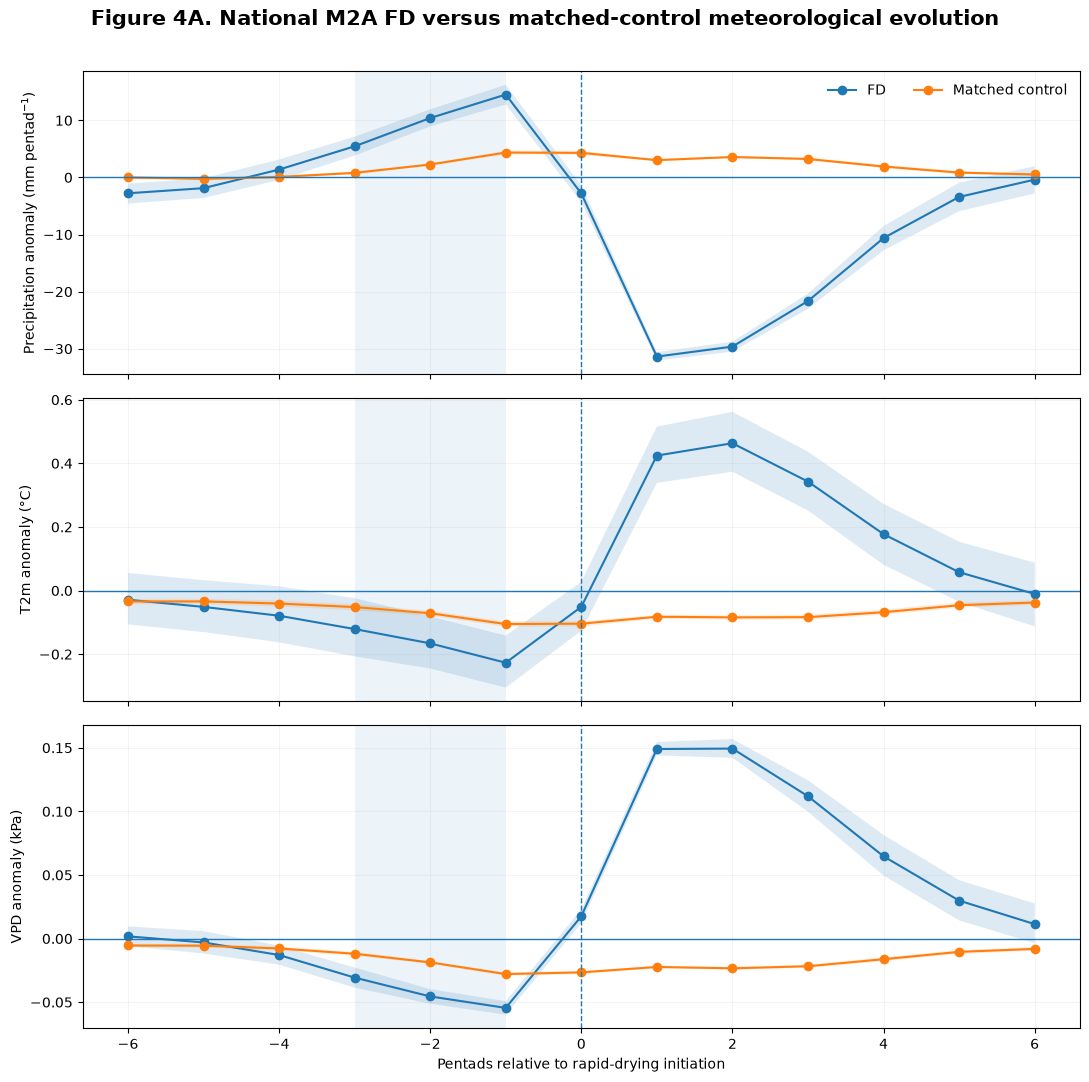

In [9]:
national=boot[(boot.scope=='national')&(boot.stratum=='Indonesia')].copy()
fig,axes=plt.subplots(3,1,figsize=(11,11),sharex=True)
for ax,(v,label) in zip(axes,VARS.items()):
    s=national[national.variable==v].sort_values('lag')
    l1=ax.plot(s.lag,s.event_mean,marker='o',label='FD')[0]; ax.fill_between(s.lag,s.event_ci_low,s.event_ci_high,alpha=.15)
    l2=ax.plot(s.lag,s.control_mean,marker='o',label='Matched control')[0]; ax.fill_between(s.lag,s.control_ci_low,s.control_ci_high,alpha=.15)
    ax.axhline(0,lw=1); ax.axvline(0,ls='--',lw=1); ax.axvspan(-3,-1,alpha=.08); ax.set_ylabel(label); ax.grid(alpha=.15)
axes[0].legend(frameon=False,ncol=2); axes[-1].set_xlabel('Pentads relative to rapid-drying initiation')
fig.suptitle('Figure 4A. National M2A FD versus matched-control meteorological evolution',fontsize=15,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.97]); fig.savefig(OUTPUT_DIR/'Figure4A_national_FD_vs_matched_control.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()

# Figure 4B — National paired difference (FD − control)
Ini figure utama untuk menjawab selection/conditioning question. Jika CI lag `−3..−1` mencakup nol, residual antecedent contrast tidak robust setelah matching.

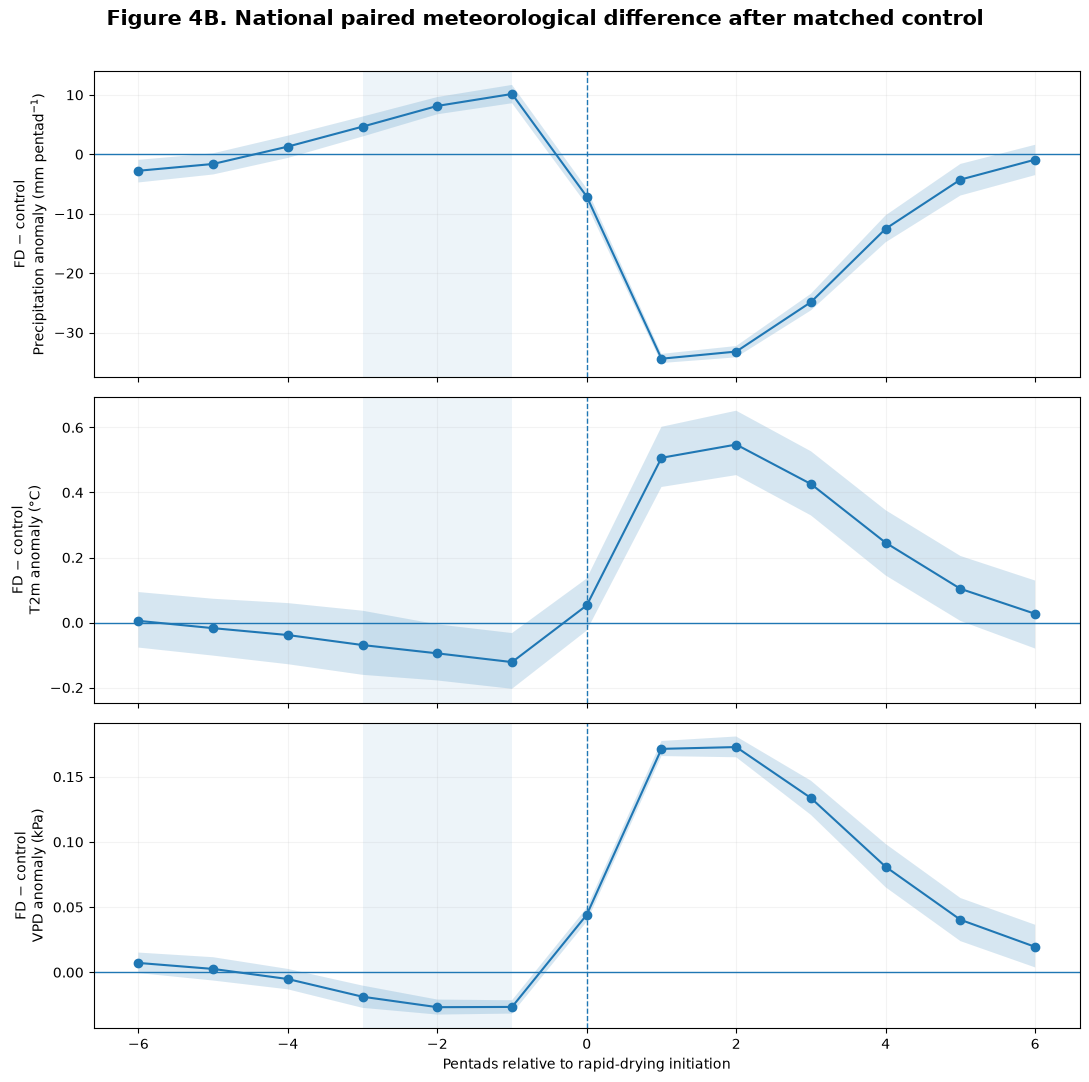

In [10]:
fig,axes=plt.subplots(3,1,figsize=(11,11),sharex=True)
for ax,(v,label) in zip(axes,VARS.items()):
    s=national[national.variable==v].sort_values('lag')
    ax.plot(s.lag,s.difference_mean,marker='o'); ax.fill_between(s.lag,s.difference_ci_low,s.difference_ci_high,alpha=.18)
    ax.axhline(0,lw=1); ax.axvline(0,ls='--',lw=1); ax.axvspan(-3,-1,alpha=.08); ax.set_ylabel('FD − control\n'+label); ax.grid(alpha=.15)
axes[-1].set_xlabel('Pentads relative to rapid-drying initiation')
fig.suptitle('Figure 4B. National paired meteorological difference after matched control',fontsize=15,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.97]); fig.savefig(OUTPUT_DIR/'Figure4B_national_matched_control_difference.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()

# Figure 4C — Per macro-island

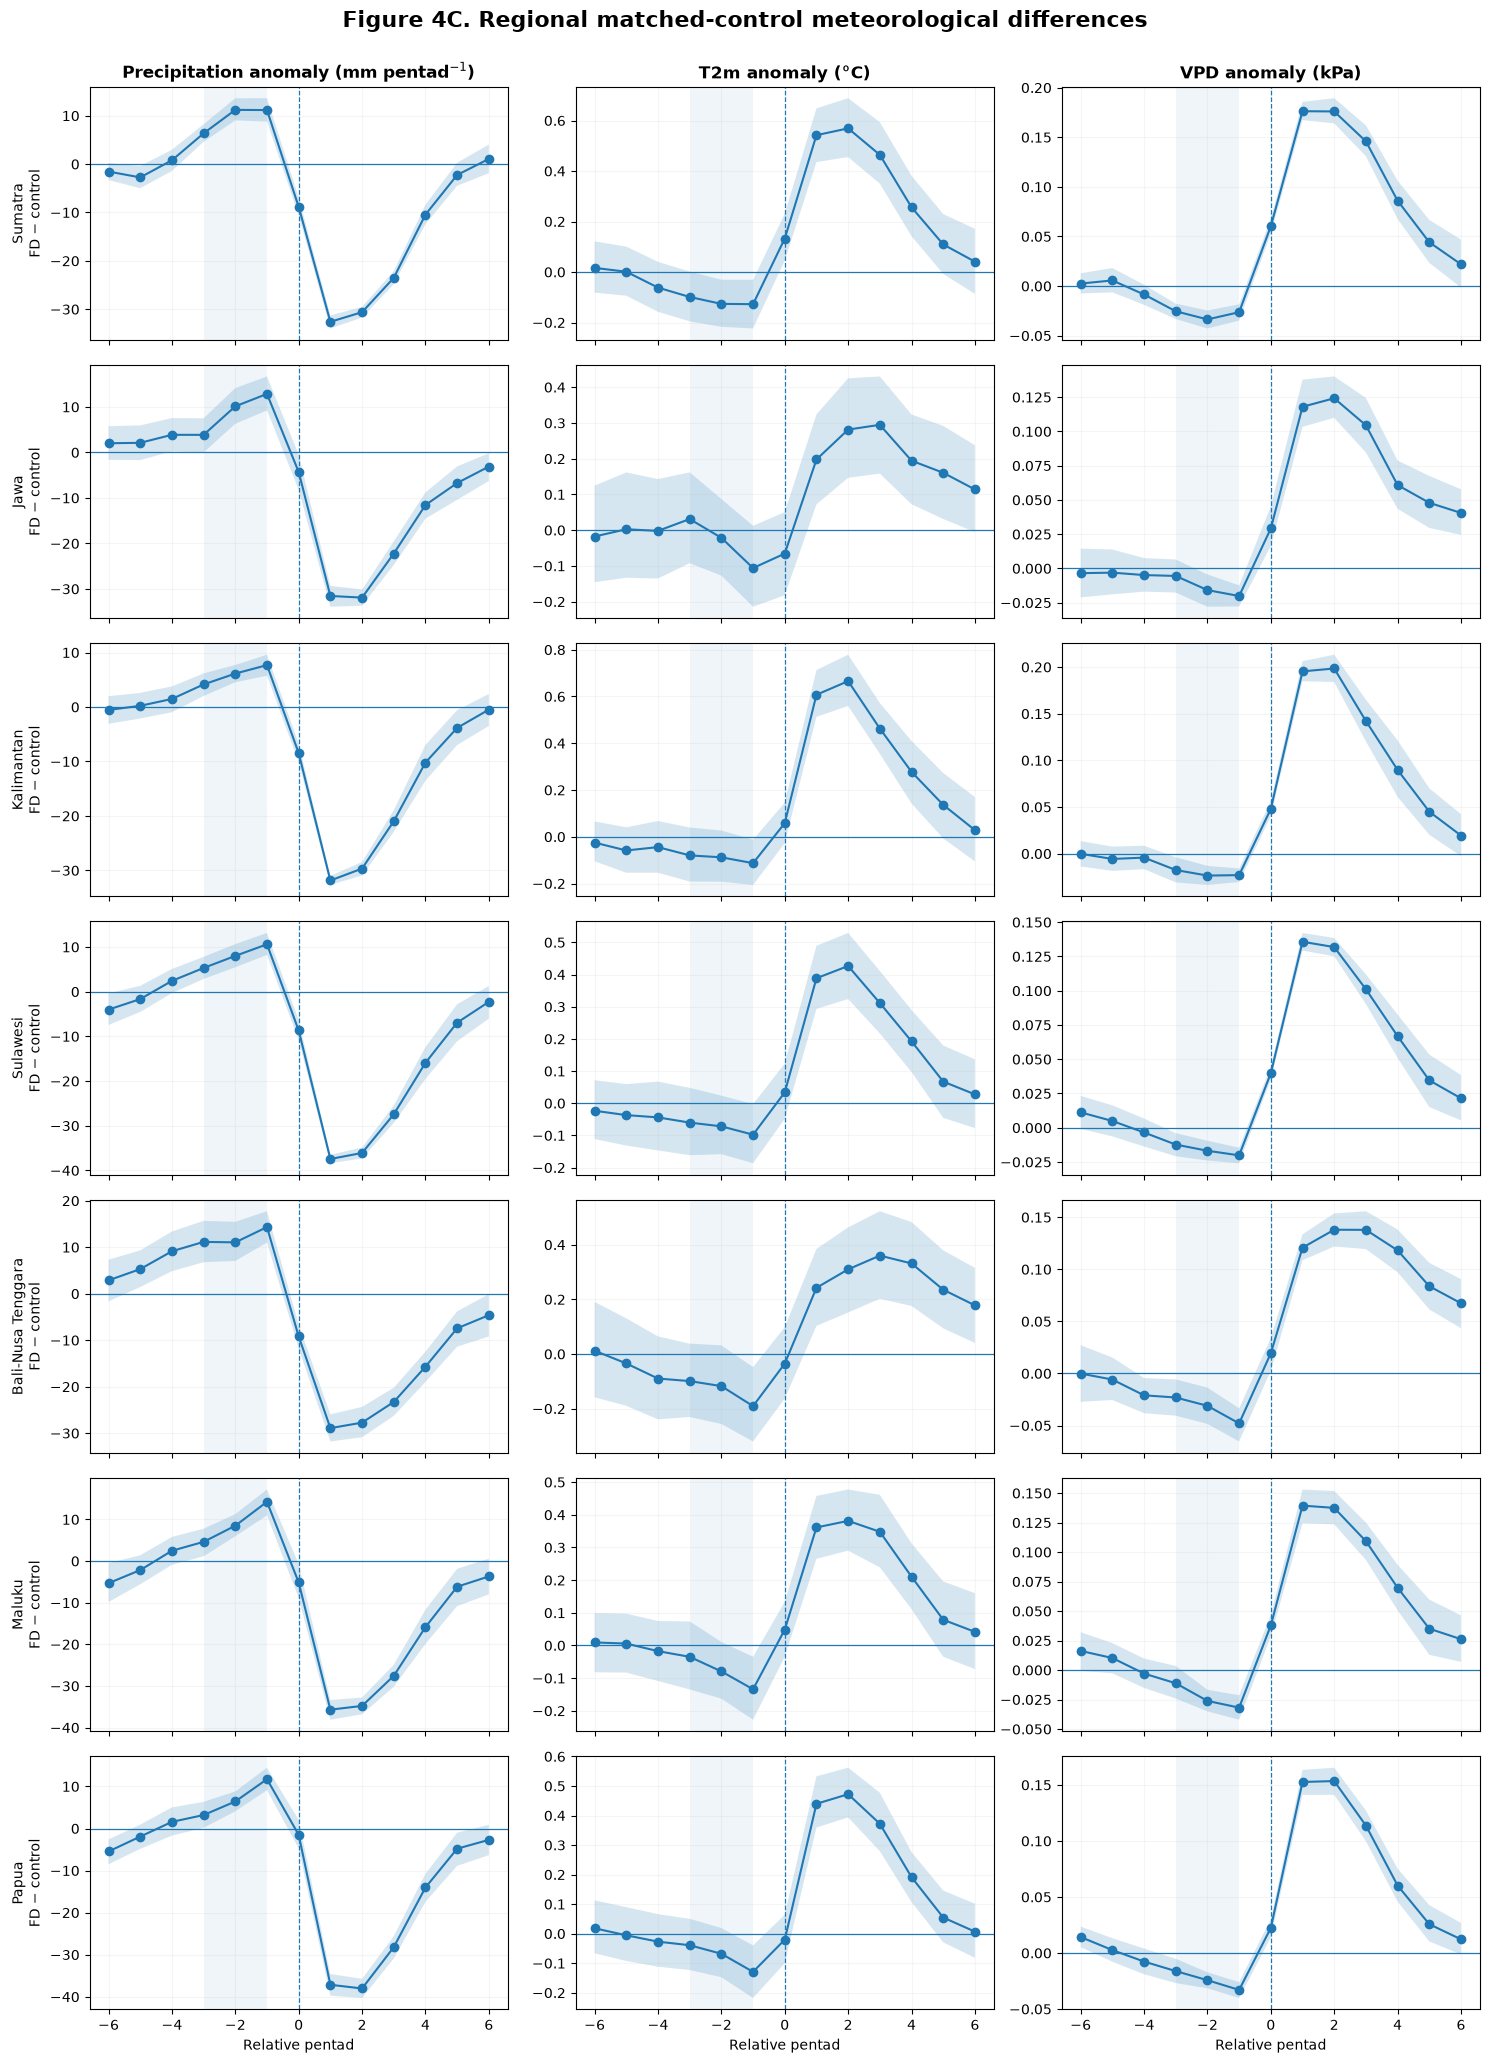

In [11]:
items=list(VARS.items()); fig,axes=plt.subplots(len(island_names),3,figsize=(15,3*len(island_names)),sharex=True)
for r,region in enumerate(island_names):
    for c,(v,label) in enumerate(items):
        ax=axes[r,c]; s=boot[(boot.scope=='region')&(boot.stratum==region)&(boot.variable==v)].sort_values('lag')
        if s.empty or s.difference_mean.isna().all(): ax.text(.5,.5,'Insufficient year-block support',ha='center',va='center',transform=ax.transAxes)
        else:
            ax.plot(s.lag,s.difference_mean,marker='o'); ax.fill_between(s.lag,s.difference_ci_low,s.difference_ci_high,alpha=.18)
        ax.axhline(0,lw=.9); ax.axvline(0,ls='--',lw=.9); ax.axvspan(-3,-1,alpha=.07); ax.grid(alpha=.12)
        if r==0: ax.set_title(label,fontweight='bold')
        if c==0: ax.set_ylabel(region+'\nFD − control')
        if r==len(island_names)-1: ax.set_xlabel('Relative pentad')
fig.suptitle('Figure 4C. Regional matched-control meteorological differences',fontsize=16,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.98]); fig.savefig(OUTPUT_DIR/'Figure4C_regional_matched_control_difference.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()

# Figure 4D — Per musim onset
DJF/MAM/JJA/SON dipakai sebagai stratifikasi sederhana. Ini **bukan** asumsi bahwa semua macro-island mempunyai monsoon regime yang identik.

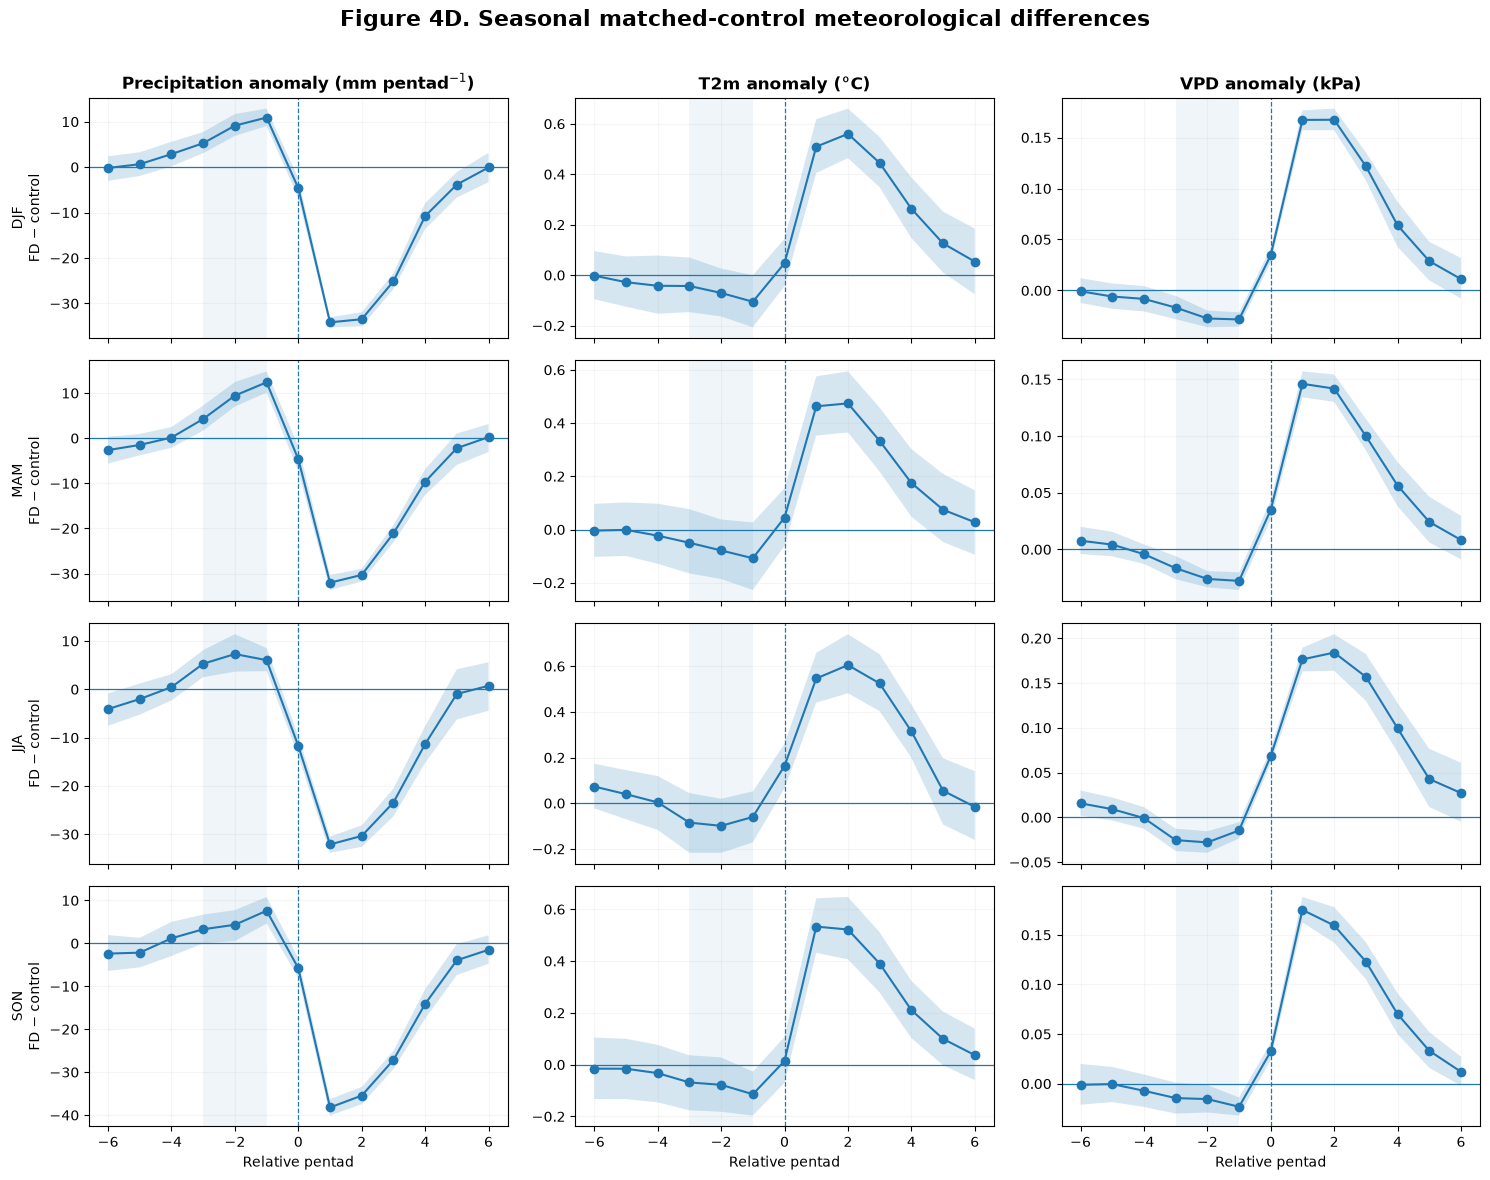

In [12]:
seasons=['DJF','MAM','JJA','SON']; fig,axes=plt.subplots(4,3,figsize=(15,12),sharex=True)
for r,sn in enumerate(seasons):
    for c,(v,label) in enumerate(items):
        ax=axes[r,c]; s=boot[(boot.scope=='season')&(boot.stratum==sn)&(boot.variable==v)].sort_values('lag')
        if s.empty or s.difference_mean.isna().all(): ax.text(.5,.5,'Insufficient year-block support',ha='center',va='center',transform=ax.transAxes)
        else:
            ax.plot(s.lag,s.difference_mean,marker='o'); ax.fill_between(s.lag,s.difference_ci_low,s.difference_ci_high,alpha=.18)
        ax.axhline(0,lw=.9); ax.axvline(0,ls='--',lw=.9); ax.axvspan(-3,-1,alpha=.07); ax.grid(alpha=.12)
        if r==0: ax.set_title(label,fontweight='bold')
        if c==0: ax.set_ylabel(sn+'\nFD − control')
        if r==3: ax.set_xlabel('Relative pentad')
fig.suptitle('Figure 4D. Seasonal matched-control meteorological differences',fontsize=16,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.97]); fig.savefig(OUTPUT_DIR/'Figure4D_seasonal_matched_control_difference.png',dpi=FIG_DPI,bbox_inches='tight'); plt.show()

## 8. Antecedent-window summary dan decision rule
`lag −3..−1` dirata-ratakan **dalam setiap event year** lebih dulu, lalu bootstrap tahun.

- precipitation residual `>0`: FD antecedent lebih wet dari matched control;
- T2m residual `<0`: lebih cool;
- VPD residual `<0`: lebih low-VPD.

In [13]:
ante=annual[annual.lag.isin([-3,-2,-1])].copy()
ante_y=ante.groupby(['scope','stratum','event_year','variable'],as_index=False).agg(antecedent_difference=('difference_mean','mean'))
rng2=np.random.default_rng(RANDOM_SEED+1); ar=[]
for (scope,stratum,v),sub in ante_y.groupby(['scope','stratum','variable'],sort=False):
    x=sub.antecedent_difference.dropna().to_numpy(float); n=len(x)
    if n>=MIN_YEARS_FOR_CI:
        idx=rng2.integers(0,n,size=(BOOTSTRAP_REPS,n)); b=x[idx].mean(1); m=float(x.mean()); lo,hi=np.quantile(b,[.025,.975])
    else: m=lo=hi=np.nan
    ar.append({'scope':scope,'stratum':stratum,'variable':v,'n_years':n,'antecedent_difference_mean':m,'ci95_low':lo,'ci95_high':hi,'ci_excludes_zero':bool(np.isfinite(lo) and (lo>0 or hi<0))})
ante_summary=pd.DataFrame(ar); ante_summary.to_csv(ANTECEDENT_FILE,index=False)
nat=ante_summary[(ante_summary.scope=='national')&(ante_summary.stratum=='Indonesia')].set_index('variable')
display(nat.reset_index())

expected={'tp_anom_mm':1,'t2m_anom_c':-1,'vpd_anom_kpa':-1}; flags=[]
for v,sgn in expected.items():
    if v not in nat.index: flags.append(False); continue
    lo,hi=nat.loc[v,'ci95_low'],nat.loc[v,'ci95_high']
    flags.append(bool(np.isfinite(lo) and ((sgn>0 and lo>0) or (sgn<0 and hi<0))))
print('\nDECISION:')
if all(flags):
    print('Residual wet/cool/low-VPD antecedent triad PERSISTS after matching.')
    print('Next: inspect regional/seasonal pattern; then test monsoon and ENSO/IOD modulation.')
else:
    print('The full wet/cool/low-VPD antecedent triad does NOT robustly persist after matching.')
    print('Initial-state/seasonal conditioning likely explains at least part of original antecedent signal.')
    print('Do not use ENSO/IOD to explain a national precursor that disappears after matching.')

,variable,scope,stratum,n_years,antecedent_difference_mean,ci95_low,ci95_high,ci_excludes_zero
0,t2m_anom_c,national,Indonesia,29,-0.095131,-0.178285,-0.000860,True
1,tp_anom_mm,national,Indonesia,29,7.649333,6.345959,8.982479,True
2,vpd_anom_kpa,national,Indonesia,29,-0.024024,-0.029524,-0.018445,True



DECISION:
Residual wet/cool/low-VPD antecedent triad PERSISTS after matching.
Next: inspect regional/seasonal pattern; then test monsoon and ENSO/IOD modulation.


## 9. Cara membaca hasil dan langkah berikutnya

### Jika matched-control difference antecedent hilang / CI mencakup 0
Interpretasi paling defensible: wet/cool/low-VPD sebelum onset sebagian besar terkait **initial-state conditioning** dan seasonality. Regional/seasonal Figure 4C–4D masih berguna, tetapi tidak perlu mengejar ENSO/IOD untuk menjelaskan precursor nasional yang tidak robust.

### Jika residual antecedent tetap kuat
Lanjutkan secara bertahap:
1. lihat region dan season mana yang mempertahankan sinyal;
2. uji **monsoon transition / break**;
3. uji **ENSO dan IOD sebagai background modulators**;
4. hanya jika skripsi ingin menjelaskan mekanisme atmosfer lebih dalam, tambahkan circulation/moisture transport.

### Circulation/moisture transport belum diperlukan untuk menjalankan notebook ini
Notebook ini hanya membutuhkan produk yang sudah ada: M2A detection, RZSM percentile, P/T2m/VPD anomaly, dan macro-island mask.

In [14]:
manifest={
 'notebook':'04c_MATCHED_CONTROL_REGIONAL_SEASONAL_M2A',
 'benchmark':'M2A / FD_BENCHMARK','analysis_period':[START_YEAR,END_YEAR],
 'matching':{'same_grid':True,'same_calendar_pentad':True,'different_year':True,'minimum_control_rzsm_percentile':MIN_CONTROL_RZSM,'rzsm_match_tolerance_pp':RZSM_MATCH_TOL,'control_fd_start_exclusion_radius_pentads':CONTROL_EXCLUSION_RADIUS,'with_replacement':True},
 'inference':{'resampling_unit':'event year','bootstrap_repetitions':BOOTSTRAP_REPS,'causal_attribution':False},
 'macro_islands':island_names,'seasons':['DJF','MAM','JJA','SON']}
with (OUTPUT_DIR/'matched_control_manifest.json').open('w',encoding='utf-8') as f: json.dump(manifest,f,ensure_ascii=False,indent=2)
fd.close(); anom.close(); pct_ds.close(); islands.close()
print('04c complete. Output:',OUTPUT_DIR)

04c complete. Output: D:\ERA5_LAND\output_fd_04c_matched_control
